## 📝[1] 패키지 가져오기
## 📝[2]데이터 가져오기 - 게임 유저 군집화
## 📝[3]데이터 전처리

In [30]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

# Elbow Point 계산 라이브러리
from kneed import KneeLocator
my_dpi = 200


In [3]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [40]:
origin = load_data("iris")
origin.head()

1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

field         description
------------  -------------
Sepal.Length  꽃밭침 길이
Sepal.Width   꽃밭침 너비
Petal.Length  꽃잎 길이
Petal.Width   꽃잎 너비
Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [41]:
df = origin.drop("Species", axis=1)
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 📘#03.최적의 클러스터 구하기

## 📝[1]이너셔:K-Means의 성능평가지표

✏️2~10 까지 군집의 수를 늘려가면서 Interia 값 수집

In [136]:
klist = list(range(2,11))

inertia = []

for k in klist:
    estimator = KMeans(n_clusters=k, random_state=0) 
    estimator.fit(X=df)
    inertia.append(estimator.inertia_)
inertia

[470.3663850931677,
 144.1568901098901,
 58.539571428571435,
 47.120360248447206,
 45.950469654528476,
 38.85854273830744,
 33.114897430605176,
 28.51158973829748,
 27.153248071630813]

## ✏️(2)Inertia 값의 변화 시각화
## 📝[2]엘보우 포인트
## ✏️(1)엘보우 포인트 직접 구하기

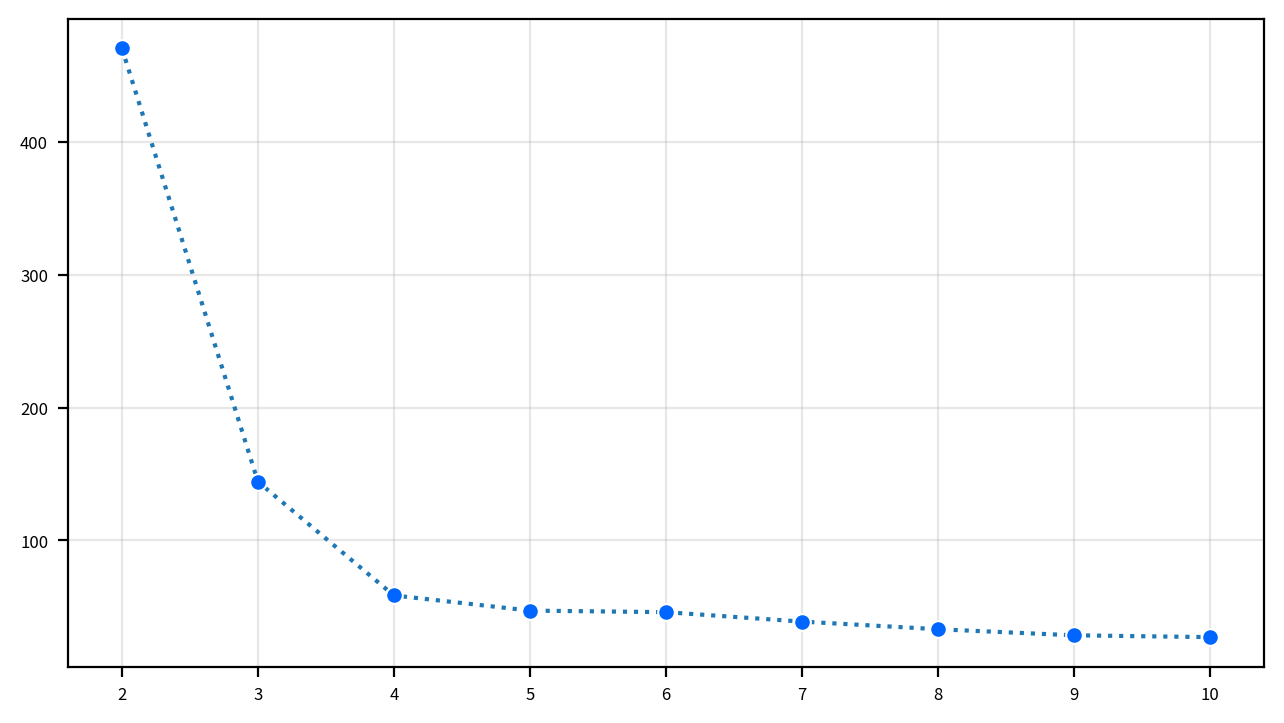

In [137]:
# 그래프 초기화
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# Line Plot
# -------------------------------
sb.lineplot(
    x=klist,
    y=inertia,
    linestyle=":",
    marker="o",
    markerfacecolor="#0066ff",
    markeredgecolor="#ffffff"
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


> 인사이트<br>
x축이 4인 지점부터 감소가 완만하게 진행되는 것으로 보인다. 그러므로 최적의 클러스터 수는 3으로 판단할 수 있다.

## 📝[2]엘보우 포인트

Numpy를 사용한 기울기(변화율) 계산

In [138]:
# 기울기 저장 리스트 (첫 값은 기준용)
slope_list = [0]

for i in range(1, len(inertia)):
    x1 = klist[i - 1]
    y1 = inertia[i - 1]

    x2 = klist[i]
    y2 = inertia[i]

    # 두 점을 지나는 1차 직선의 기울기 계산
    slope, _ = np.polyfit(
        [x1, x2],
        [y1, y2],
        1
    )

    slope_list.append(slope)


slope_list


[0,
 np.float64(-326.2094949832773),
 np.float64(-85.61731868131862),
 np.float64(-11.419211180124266),
 np.float64(-1.1698905939187338),
 np.float64(-7.091926916221023),
 np.float64(-5.743645307702249),
 np.float64(-4.603307692307677),
 np.float64(-1.3583416666666634)]

기울기의 평균(변화율의 평균)

In [141]:
avg_slope = np.mean(slope_list)
avg_slope

np.float64(-49.245904113504054)

기울기가 평균보다 작은 지점 찾기(평균 변화율보다 크게 감소한 첫 번째 지점 찾기)

In [142]:
ev = []
ei = []

for i, v in enumerate(slope_list):
    if v < avg_slope:
        ev.append(v)
        ei.append(i)

elbow_point = ei[np.argmax(ev)]
elbow_point

2

최적의 군집수

In [145]:
best_k = klist[elbow_point]
best_k

4

Elbow Point를 포함한 Inertia 시각화

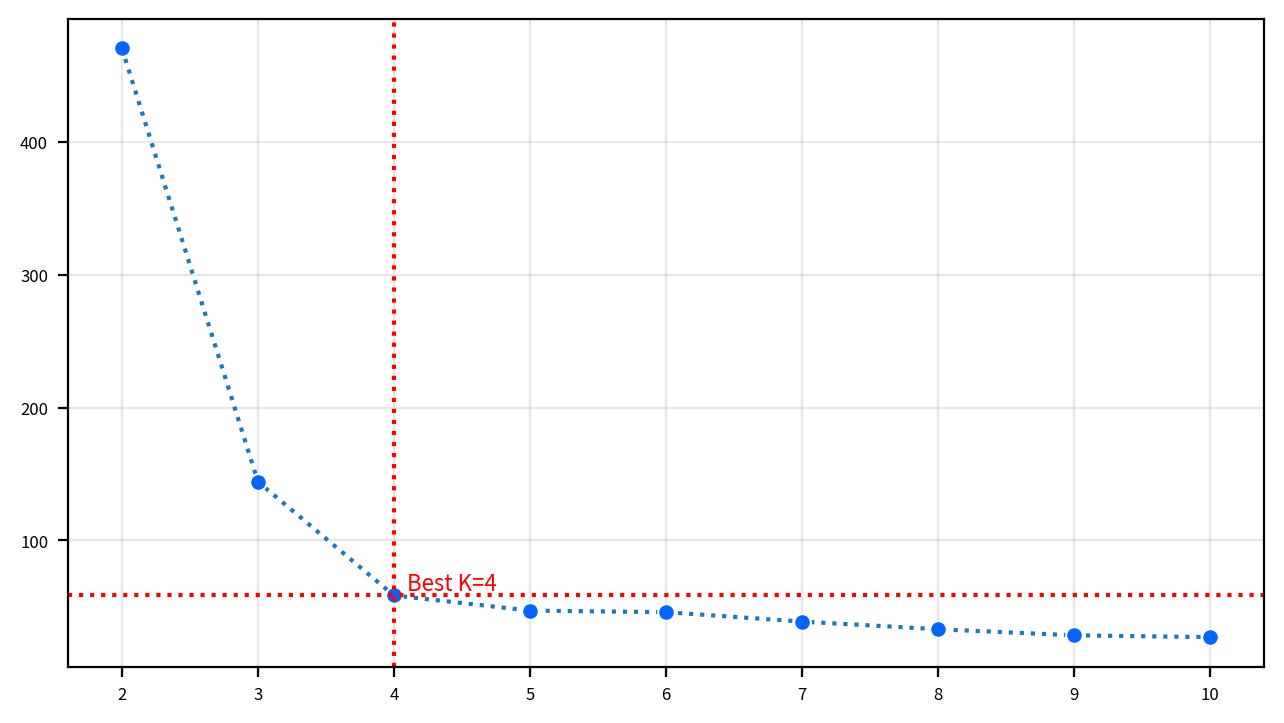

In [158]:
# 그래프 초기화
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# Line Plot
# -------------------------------
sb.lineplot(
    x=klist,
    y=inertia,
    linestyle=":",
    marker="o",
    markerfacecolor="#0066ff",
    markeredgecolor="#ffffff"
)


# -------------------------------
# 엘보우 포인트 표시
# -------------------------------
ax.axvline(
    x=best_k,
    color="red",
    linestyle=":"
)

ax.axhline(y=best_y, color="red", linestyle=":")

ax.text(
    best_k + 0.1,
    inertia[elbow_point] + 0.1,
    f"Best K=%d" % best_k,
    fontsize=8,
    ha="left",
    va="bottom",
    color="r"
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


## ✏️(2)엘보우 포인트 자동 구하기

In [160]:
k1 = KneeLocator(klist, inertia, curve="convex", direction="decreasing")
best_k = k1.elbow
best_y = k1.elbow_y
print("found elbow:", best_k)
print("found y:",best_y)

found elbow: 4
found y: 58.539571428571435


## ✏️(3)도출된 결과를 적용한 클러스터링

In [168]:
estimator = KMeans(n_clusters=best_k)
estimator.fit(df)
cluster = estimator.predict(df)
df["ClusterID"] = cluster
df

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,ClusterID
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,3
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [149]:
print(df.columns.tolist())
df.drop(columns=["Cluster ID"], inplace=True)


['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width', 'ClusterID']


KeyError: "['Cluster ID'] not found in axis"

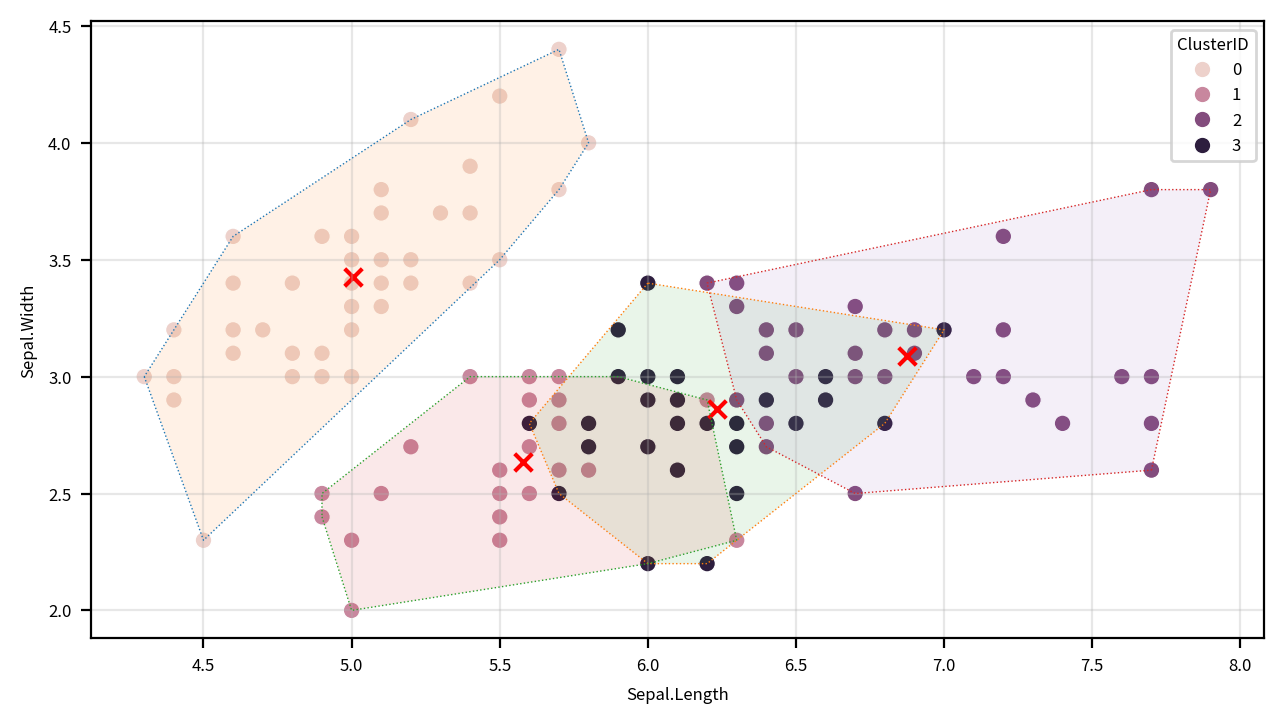

In [172]:
# 데이터 복사 및 컬럼 설정
vdf = df.copy()

hue_field = "ClusterID"
x_field = "Sepal.Length"
y_field = "Sepal.Width"


# -------------------------------
# 그래프 초기화
# -------------------------------
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 데이터 산점도
# -------------------------------
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field
)


# -------------------------------
# 군집별 Convex Hull
# -------------------------------
for c in vdf[hue_field].unique():

    # 군집별 데이터프레임 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        # 외곽선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except :
        pass


# -------------------------------
# 군집 중심점 표시
# -------------------------------
ax.scatter(
    estimator.cluster_centers_[:, 0],
    estimator.cluster_centers_[:, 1],
    marker="x",
    c="red",
    alpha=1,
    s=40
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()     # 그래프 화면 출력
plt.close()    # 그래프 작업 종료
